In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
df=pd.read_csv('files/co2.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
#EDA: Initial Data analysis 
df.shape

(7385, 12)

In [5]:
#EDA:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')

In [ ]:
#EDA:
df.info()
#if non-null < no.of rows then missing values exist 
#object is string/categorical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [7]:
#EDA: Statistical Summary 
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [8]:
#EDA: Check missing values
df.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [11]:
#EDA: Data Cleaning and Preprocessing 
# Finding inconsistencies 
obj_cols=df.select_dtypes(include='object')
for col in obj_cols:
    print(f"The value count for {col} is:")
    print(df[col].value_counts())


The value count for Make is:
Make
FORD             628
CHEVROLET        588
BMW              527
MERCEDES-BENZ    419
PORSCHE          376
TOYOTA           330
GMC              328
AUDI             286
NISSAN           259
JEEP             251
DODGE            246
KIA              231
HONDA            214
HYUNDAI          210
MINI             204
VOLKSWAGEN       197
MAZDA            180
LEXUS            178
JAGUAR           160
CADILLAC         158
SUBARU           140
VOLVO            124
INFINITI         108
BUICK            103
RAM               97
LINCOLN           96
MITSUBISHI        95
CHRYSLER          88
LAND ROVER        85
FIAT              73
ACURA             72
MASERATI          61
ROLLS-ROYCE       50
ASTON MARTIN      47
BENTLEY           46
LAMBORGHINI       41
ALFA ROMEO        30
GENESIS           25
SCION             22
SMART              7
BUGATTI            3
SRT                2
Name: count, dtype: int64
The value count for Model is:
Model
F-150 FFV             

In [ ]:
#EDA: data visualisation of CO2 dataset
# check correlation of CO2 Emissions(g/km) with numeric cols
num_cols=df.select_dtypes(include=['int64','float64'])
y=df['CO2 Emissions(g/km)']
num_cols.corr()[y.name].sort_values(ascending=False)

#we choose predictors from this: We choose Fuel Cosumption Comb(L/100 km), Engine Size(L),Cylinders have positive correlation. 
#Fuel Cosumption Comb(L/100 km has strong correlation)
#Fuel Consumption Comb(mpg) is inverse of Fuel Consumption Comb(L/100 km)


CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64

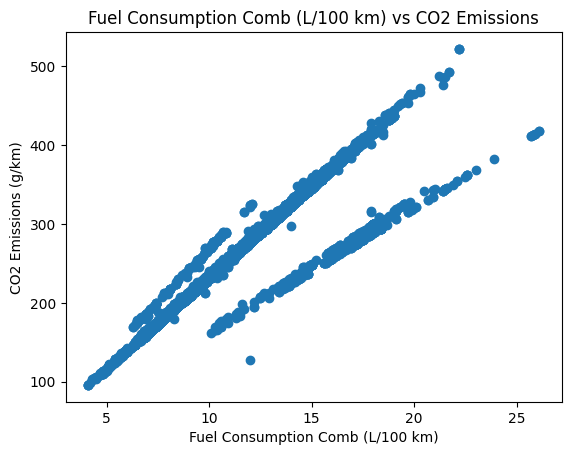

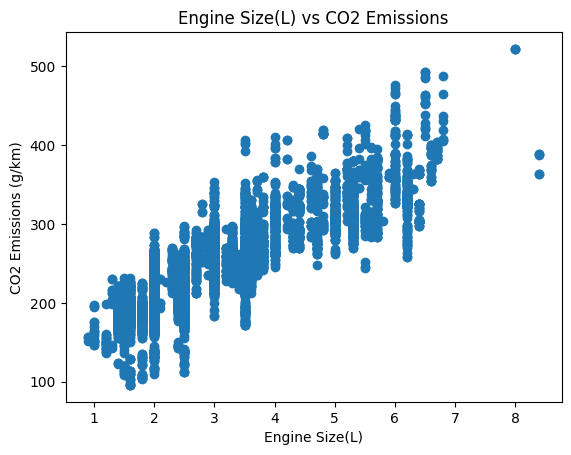

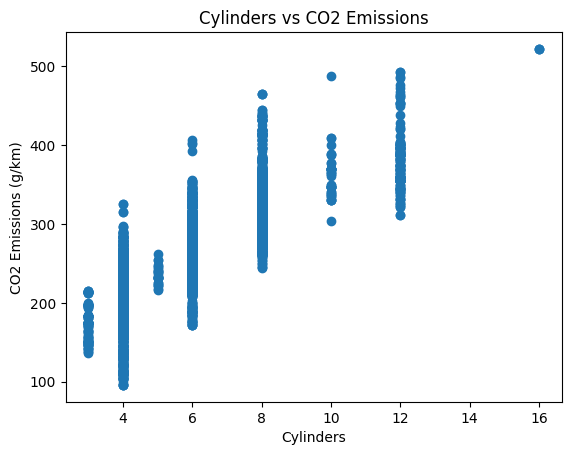

In [21]:


features = [
    'Fuel Consumption Comb (L/100 km)',
    'Engine Size(L)',
    'Cylinders']

y = df['CO2 Emissions(g/km)']

for col in features:
    plt.scatter(df[col], y)
    plt.xlabel(col)
    plt.ylabel("CO2 Emissions (g/km)")
    plt.title(f"{col} vs CO2 Emissions")
    plt.show()


In [23]:
#From the scatter plots we understand that Fuel Cosumption Comb(L/100) can be the strongest predcitor, due to strong linear association.
#Linear Regression b/w Fuel Consumption and CO2 emissions:


# Predictor and target
x = df['Fuel Consumption Comb (L/100 km)'].values
y = df['CO2 Emissions(g/km)'].values


Q1 = df['Fuel Consumption Comb (L/100 km)'].quantile(0.25)
Q3 = df['Fuel Consumption Comb (L/100 km)'].quantile(0.75)
IQR = Q3 - Q1

Outliers are below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
outliers = df[(df['Fuel Consumption Comb (L/100 km)'] < Q1 - 1.5*IQR) |
              (df['Fuel Consumption Comb (L/100 km)'] > Q3 + 1.5*IQR)]

print("Number of outliers:", len(outliers))
print(outliers)

In [29]:
#Compute m and c from y=mx+c 
#m=CoVar(x and y)/Var of x, c=y'-mx'

x_mean=np.mean(x)
y_mean=np.mean(y)

#Computing m
covar=np.sum((x-x_mean)*(y-y_mean))
varx=np.sum((x-x_mean)**2)
m=covar/varx

#Computing c:
c=(y_mean-(m*x_mean))

print(f"Slope is {m}")
print(f"x-intercept is {c}")

Slope is 18.57131902142713
x-intercept is 46.763152217496526


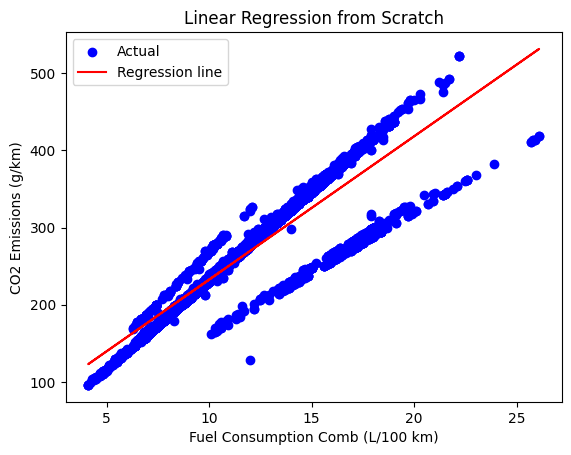

In [38]:
#Make predictions 
y_pred=m*x+c

# Plot regression line
plt.scatter(x,y,color='blue',label='Actual')
plt.plot(x,y_pred,color='red',label='Regression line')
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('CO2 Emissions (g/km)')
plt.title('Linear Regression from Scratch')
plt.legend()
plt.show()



In [ ]:
#Evaluate the model:
# Root Mean Squared Error
mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)

# R-squared
ss_total = np.sum((y - y_mean)**2)
ss_res = np.sum((y - y_pred)**2)
r2 = 1 - (ss_res/ss_total)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")



RMSE: 23.196423677215428
R-squared: 0.8428186895623989
